### Import libraries

In [300]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "data").exists():
    raise FileNotFoundError("Project data directory not found.")

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "tourism_arrivals_clean.csv"
OUTPUT_PATH = PROJECT_ROOT / "outputs"
FIGURES_PATH = OUTPUT_PATH / "figures"
TABLES_PATH = OUTPUT_PATH / "tables"
FIGURES_PATH.mkdir(parents=True, exist_ok=True)
TABLES_PATH.mkdir(parents=True, exist_ok=True)
MONTHS = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]


In [301]:
df = pd.read_csv(DATA_PATH)

yearly = (
    df.groupby("Year")["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

yearly

,Year,Tourist_Arrivals
0,2018,2333796.0
1,2019,1913702.0
2,2020,507699.0
3,2021,194495.0
4,2022,719978.0
5,2023,1487303.0
6,2024,2053465.0
7,2025,2362521.0


### Line chart of Sri Lanka Tourism Arrivals

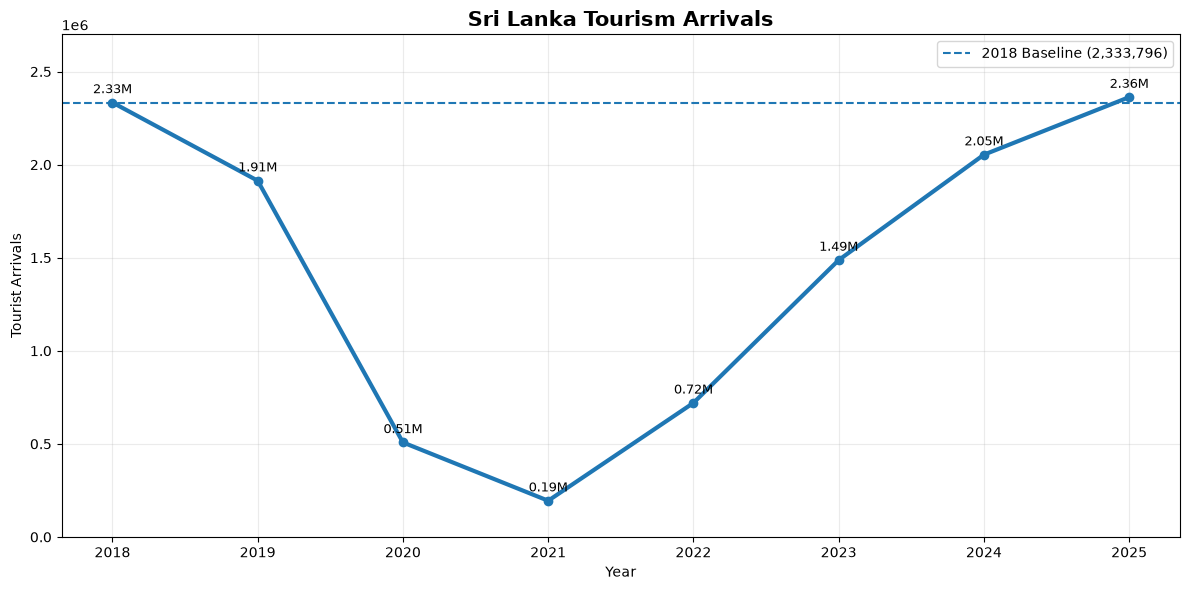

In [302]:
plt.figure(figsize=(12, 6))

plt.plot(
    yearly['Year'],
    yearly['Tourist_Arrivals'],
    marker='o',
    linewidth=3
)

base_2018 = yearly.loc[
    yearly['Year'] == 2018, 'Tourist_Arrivals'
].values[0]

plt.axhline(
    base_2018,
    linestyle='--',
    label=f'2018 Baseline ({base_2018:,.0f})'
)

# Labels
for _, row in yearly.iterrows():
    plt.text(
        row['Year'],
        row['Tourist_Arrivals'] + 50000,
        f"{row['Tourist_Arrivals']/1e6:.2f}M",
        ha='center',
        fontsize=9
    )

plt.title(
    'Sri Lanka Tourism Arrivals',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Year')
plt.ylabel('Tourist Arrivals')

plt.xticks(yearly['Year'])
plt.ylim(0, 2_700_000)
plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()
plt.show()

### Year over Year growth analysis

In [303]:
yearly = (
    df.groupby("Year")["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

yearly["YoY_Growth_%"] = (
    yearly["Tourist_Arrivals"]
    .pct_change()
    * 100
)

yearly

,Year,Tourist_Arrivals,YoY_Growth_%
0,2018,2333796.0,NaN
1,2019,1913702.0,-18.000459
2,2020,507699.0,-73.470321
3,2021,194495.0,-61.690884
4,2022,719978.0,270.178154
5,2023,1487303.0,106.576173
6,2024,2053465.0,38.066352
7,2025,2362521.0,15.050463


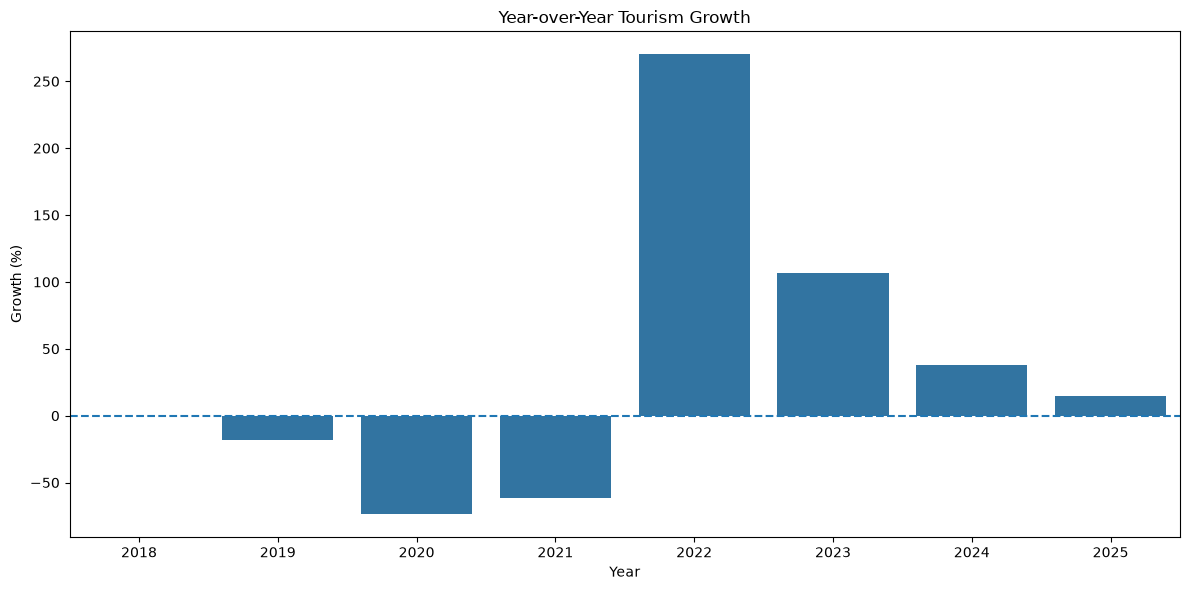

In [304]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=yearly,
    x="Year",
    y="YoY_Growth_%"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Year-over-Year Tourism Growth")
plt.ylabel("Growth (%)")

plt.tight_layout()
plt.show()

###  Monthly and seasonality analysis

In [305]:
monthly = (
    df.groupby(
        ["Month_Number", "Month"]
    )["Tourist_Arrivals"]
    .sum()
    .reset_index()
    .sort_values("Month_Number")
)

monthly

,Month_Number,Month,Tourist_Arrivals
0,1,January,1359164.0
1,2,February,1361234.0
2,3,March,1224134.0
3,4,April,843525.0
4,5,May,527328.0
5,6,June,596469.0
6,7,July,914345.0
7,8,August,885995.0
8,9,September,694060.0
9,10,October,746962.0


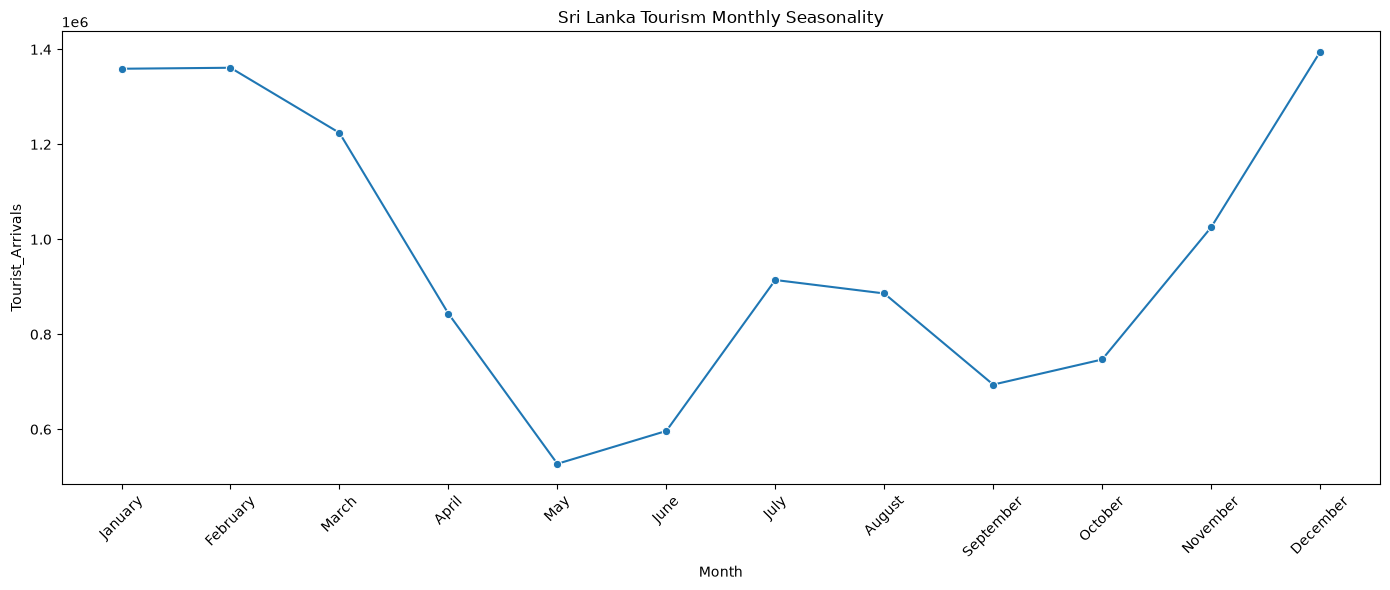

In [306]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly,
    x="Month",
    y="Tourist_Arrivals",
    marker="o"
)

plt.xticks(rotation=45)
plt.title("Sri Lanka Tourism Monthly Seasonality")

plt.tight_layout()
plt.show()

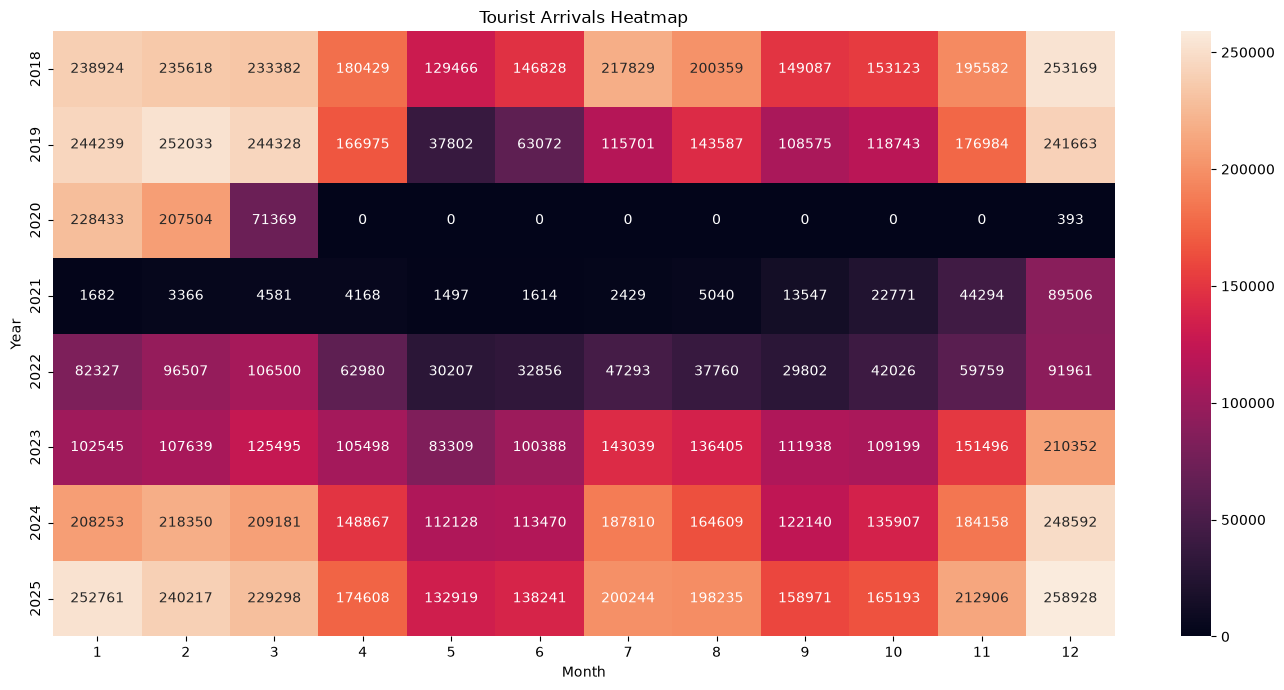

In [307]:
heatmap_data = df.pivot_table(
    index="Year",
    columns="Month_Number",
    values="Tourist_Arrivals",
    aggfunc="sum"
)

plt.figure(figsize=(14, 7))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f"
)

plt.title("Tourist Arrivals Heatmap")
plt.xlabel("Month")
plt.ylabel("Year")

plt.tight_layout()
plt.show()

### Country market analysis

In [308]:
country = (
    df.groupby("Country")["Tourist_Arrivals"]
    .sum()
    .reset_index()
    .sort_values(
        "Tourist_Arrivals",
        ascending=False
    )
)

country.head(20)

,Country,Tourist_Arrivals
234,India,1374333.0
416,Russian Federation,677270.0
541,United Kingdom,605891.0
531,UNITED KINGDOM,525053.0
220,INDIA,500627.0
198,Germany,442131.0
221,"INDIA, REPUBLIC OF",424887.0
182,GERMANY,338736.0
119,China,337220.0
31,Australia,297420.0


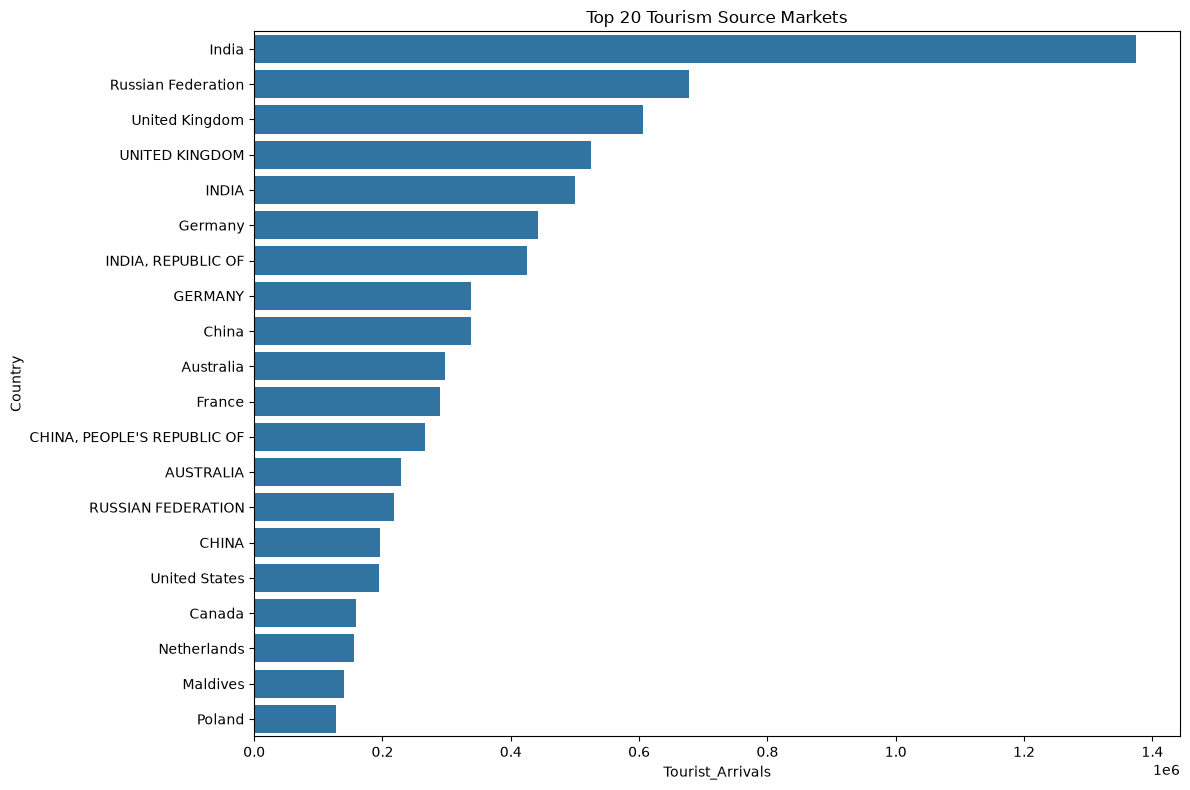

In [309]:
top20 = country.head(20)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=top20,
    y="Country",
    x="Tourist_Arrivals"
)

plt.title("Top 20 Tourism Source Markets")
plt.tight_layout()
plt.show()

### Country market share analysis

In [310]:
country = (
    df.groupby("Country")["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

total_arrivals = country[
    "Tourist_Arrivals"
].sum()

country["Market_Share_%"] = (
    country["Tourist_Arrivals"]
    / total_arrivals
    * 100
)

country = country.sort_values(
    "Market_Share_%",
    ascending=False
)

country.head(20)

,Country,Tourist_Arrivals,Market_Share_%
234,India,1374333.0,11.875381
416,Russian Federation,677270.0,5.852177
541,United Kingdom,605891.0,5.235403
531,UNITED KINGDOM,525053.0,4.536895
220,INDIA,500627.0,4.325834
198,Germany,442131.0,3.820380
221,"INDIA, REPUBLIC OF",424887.0,3.671377
182,GERMANY,338736.0,2.926961
119,China,337220.0,2.913862
31,Australia,297420.0,2.569956


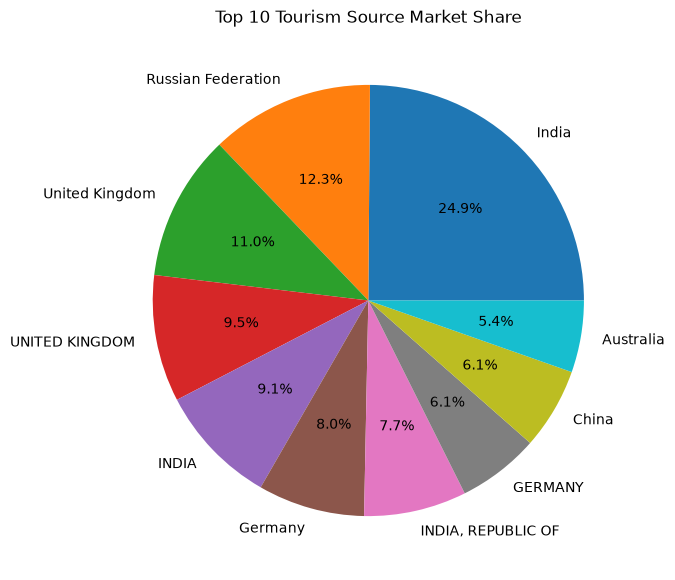

In [311]:
top10 = country.head(10)

plt.figure(figsize=(10, 7))

plt.pie(
    top10["Market_Share_%"],
    labels=top10["Country"],
    autopct="%1.1f%%"
)

plt.title("Top 10 Tourism Source Market Share")
plt.show()

### Country growth analysis

In [312]:
country_year = (
    df.groupby(
        ["Country", "Year"]
    )["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

country_year["Growth_%"] = (
    country_year
    .groupby("Country")["Tourist_Arrivals"]
    .pct_change()
    * 100
)

country_year.head()

,Country,Year,Tourist_Arrivals,Growth_%
0,A,2021,0.0,NaN
1,AFGHANISTAN,2019,473.0,NaN
2,AFGHANISTAN,2020,146.0,-69.133192
3,AFGHANISTAN,2021,15.0,-89.726027
4,"AFGHANISTAN, ISLAMIC REPUBLIC OF",2018,861.0,NaN


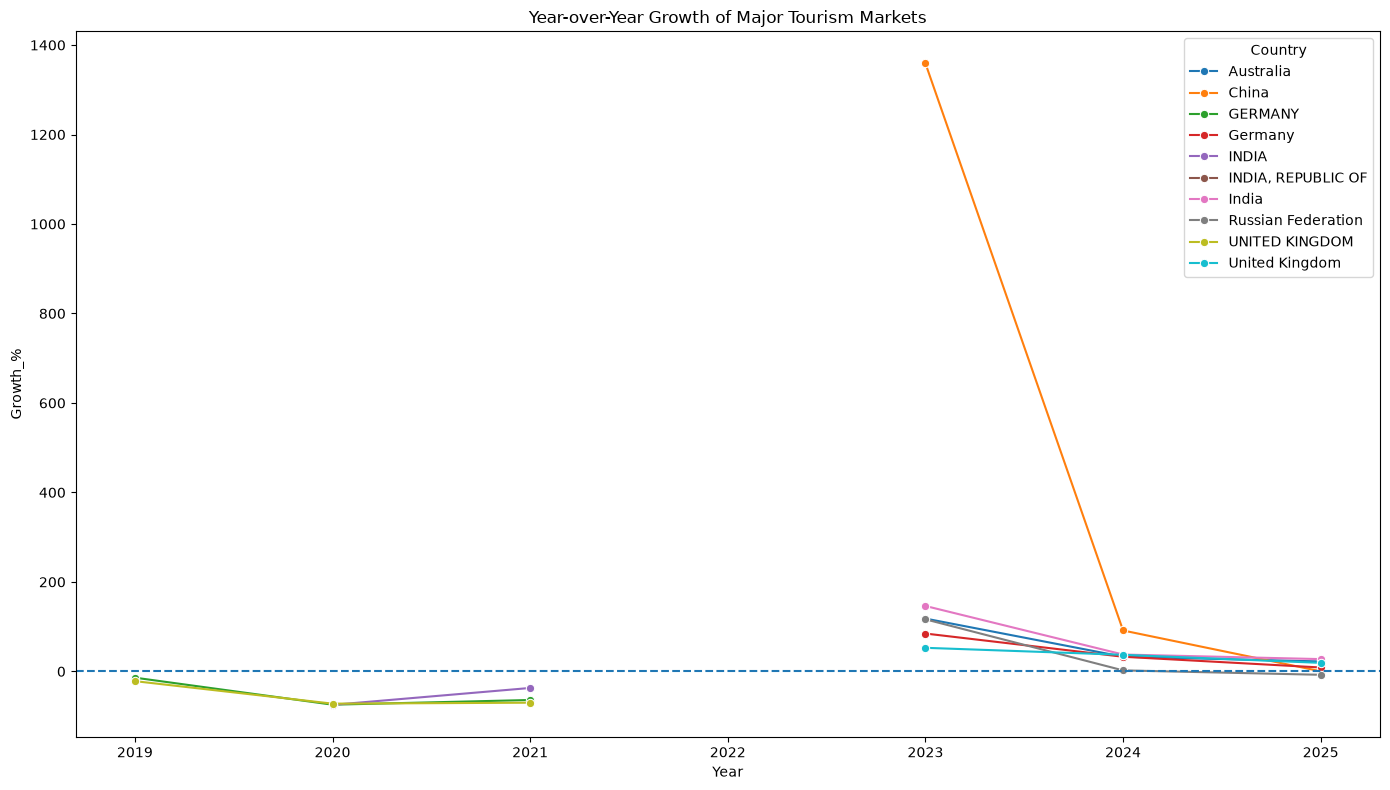

In [313]:
top_countries = (
    country_year
    .groupby("Country")["Tourist_Arrivals"]
    .sum()
    .nlargest(10)
    .index
)

growth_top = country_year[
    country_year["Country"].isin(top_countries)
]

plt.figure(figsize=(14, 8))

sns.lineplot(
    data=growth_top,
    x="Year",
    y="Growth_%",
    hue="Country",
    marker="o"
)

plt.title(
    "Year-over-Year Growth of Major Tourism Markets"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.tight_layout()
plt.show()

### Country ranking analysis

In [314]:
country_year = (
    df.groupby(
        ["Year", "Country"]
    )["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

country_year["Rank"] = (
    country_year
    .groupby("Year")["Tourist_Arrivals"]
    .rank(
        method="min",
        ascending=False
    )
)

country_year["Rank"] = (
    country_year["Rank"]
    .astype(int)
)

country_year.head()

,Year,Country,Tourist_Arrivals,Rank
0,2018,"AFGHANISTAN, ISLAMIC REPUBLIC OF",861.0,77
1,2018,"ALBANIA, REPUBLIC OF",177.0,106
2,2018,"ALGERIA, PEOPLE'S DEMOCRATIC REPUBLIC OF",368.0,94
3,2018,"ANDORRA, PRINCIPALITY OF",53.0,131
4,2018,"ANGOLA, REPUBLIC OF",9.0,173


In [315]:
top10_each_year = country_year[
    country_year["Rank"] <= 10
].sort_values(
    ["Year", "Rank"]
)

top10_each_year

,Year,Country,Tourist_Arrivals,Rank
74,2018,"INDIA, REPUBLIC OF",424887.0,1
35,2018,"CHINA, PEOPLE'S REPUBLIC OF",265965.0,2
186,2018,UNITED KINGDOM,254176.0,3
62,2018,GERMANY,156888.0,4
8,2018,AUSTRALIA,110928.0,5
...,...,...,...,...
1372,2025,Australia,109487.0,6
1423,2025,France,109041.0,7
1550,2025,United States,65973.0,8
1484,2025,Netherlands,64164.0,9


### Regional market analysis

In [316]:
import country_converter as coco

df["Continent"] = coco.convert(
    df["Country"],
    to="continent",
    not_found=None
)

df[
    ["Country", "Continent"]
].drop_duplicates().head(20)

NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
Country not found in regex
KOSOVAR not found in regex
Country not found in regex
KOSOVAR not found in regex
Coun

,Country,Continent
0,"AFGHANISTAN, ISLAMIC REPUBLIC OF",Asia
1,"ALBANIA, REPUBLIC OF",Europe
2,"ALGERIA, PEOPLE'S DEMOCRATIC REPUBLIC OF",Africa
3,"ANDORRA, PRINCIPALITY OF",Europe
4,"ANGOLA, REPUBLIC OF",Africa
5,ANTIGUA & BARBUDA,America
6,ARGENTINA,America
7,"ARMENIA, REPUBLIC OF",Asia
8,AUSTRALIA,Oceania
9,AUSTRIA,Europe


### Tourism concentration pareto analysis

In [317]:
country = (
    df.groupby("Country")["Tourist_Arrivals"]
    .sum()
    .reset_index()
    .sort_values(
        "Tourist_Arrivals",
        ascending=False
    )
)

country["Cumulative_Arrivals"] = (
    country["Tourist_Arrivals"].cumsum()
)

country["Cumulative_%"] = (
    country["Cumulative_Arrivals"]
    / country["Tourist_Arrivals"].sum()
    * 100
)

country.head(20)

,Country,Tourist_Arrivals,Cumulative_Arrivals,Cumulative_%
234,India,1374333.0,1374333.0,11.875381
416,Russian Federation,677270.0,2051603.0,17.727558
541,United Kingdom,605891.0,2657494.0,22.962960
531,UNITED KINGDOM,525053.0,3182547.0,27.499855
220,INDIA,500627.0,3683174.0,31.825690
198,Germany,442131.0,4125305.0,35.646069
221,"INDIA, REPUBLIC OF",424887.0,4550192.0,39.317447
182,GERMANY,338736.0,4888928.0,42.244408
119,China,337220.0,5226148.0,45.158269
31,Australia,297420.0,5523568.0,47.728226


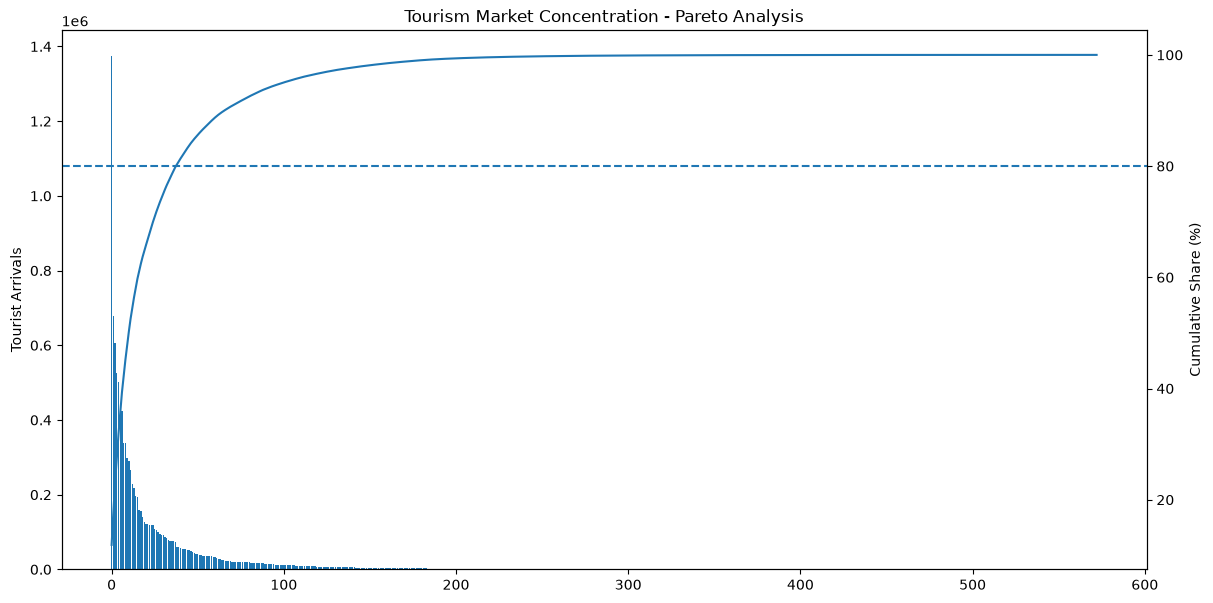

In [318]:
fig, ax1 = plt.subplots(figsize=(14, 7))

ax1.bar(
    range(len(country)),
    country["Tourist_Arrivals"]
)

ax1.set_ylabel("Tourist Arrivals")
ax2 = ax1.twinx()
ax2.plot(
    range(len(country)),
    country["Cumulative_%"]
)

ax2.axhline(
    80,
    linestyle="--"
)

ax2.set_ylabel("Cumulative Share (%)")

plt.title("Tourism Market Concentration - Pareto Analysis")
plt.show()

### Tourism distribution and outlier analysis

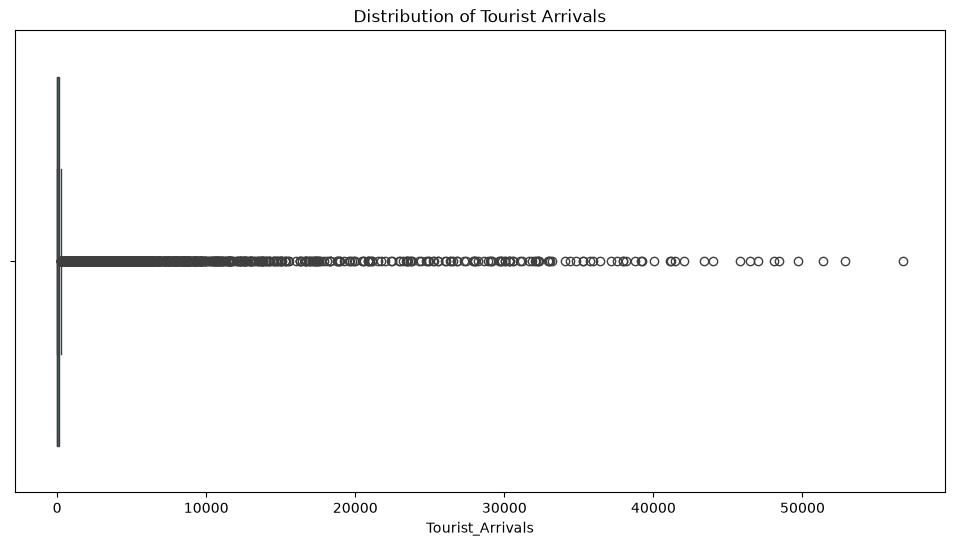

In [319]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    x=df["Tourist_Arrivals"]
)

plt.title("Distribution of Tourist Arrivals")
plt.show()

In [320]:
Q1 = df["Tourist_Arrivals"].quantile(0.25)
Q3 = df["Tourist_Arrivals"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Tourist_Arrivals"] < lower)
    |
    (df["Tourist_Arrivals"] > upper)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Outliers:", len(outliers))

Q1: 0.0
Q3: 116.0
IQR: 116.0
Outliers: 3397


### Pre crisis vs Post crisis analysis

In [321]:
df["Period"] = np.select(
    [
        df["Year"] <= 2019,
        df["Year"].isin([2020, 2021]),
        df["Year"] >= 2022
    ],
    [
        "Pre-Crisis",
        "Crisis",
        "Post-Crisis"
    ],
    default="Other"
)

period_summary = (
    df.groupby("Period")["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

period_summary

,Period,Tourist_Arrivals
0,Crisis,702194.0
1,Post-Crisis,6623267.0
2,Pre-Crisis,4247498.0


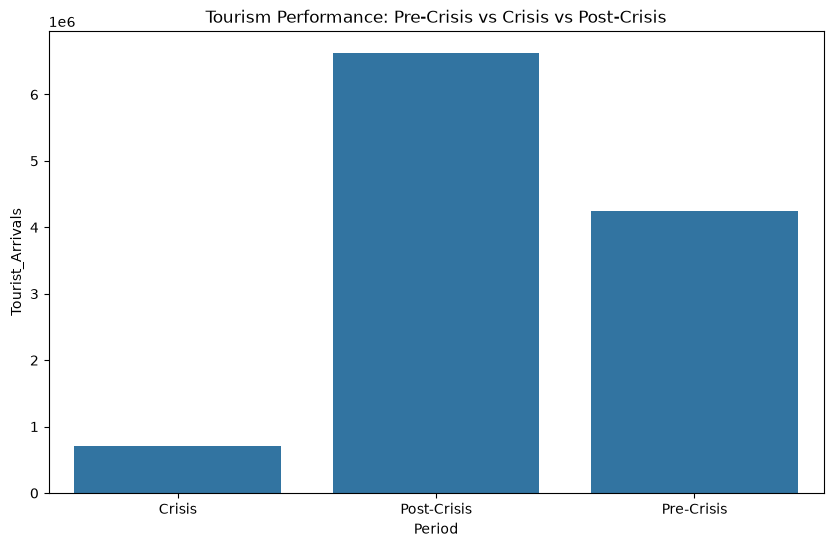

In [322]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=period_summary,
    x="Period",
    y="Tourist_Arrivals"
)

plt.title("Tourism Performance: Pre-Crisis vs Crisis vs Post-Crisis")
plt.show()

### Tourism recovery analysis

In [323]:
yearly = (
    df.groupby("Year")["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

baseline = yearly.loc[
    yearly["Year"] == 2019,
    "Tourist_Arrivals"
].iloc[0]

yearly["Recovery_Index"] = (
    yearly["Tourist_Arrivals"]
    / baseline
    * 100
)

yearly

,Year,Tourist_Arrivals,Recovery_Index
0,2018,2333796.0,121.951903
1,2019,1913702.0,100.000000
2,2020,507699.0,26.529679
3,2021,194495.0,10.163286
4,2022,719978.0,37.622263
5,2023,1487303.0,77.718631
6,2024,2053465.0,107.303279
7,2025,2362521.0,123.452920


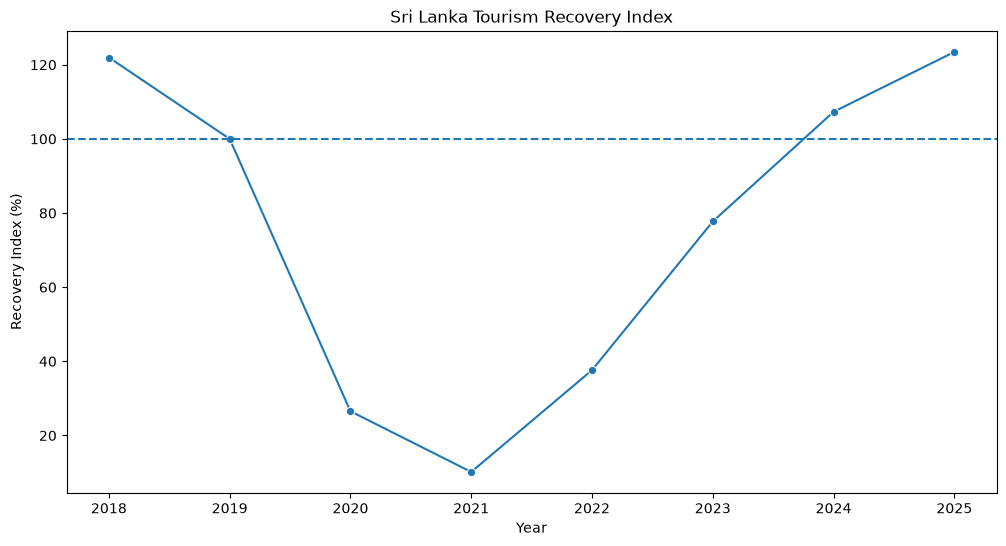

In [324]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=yearly,
    x="Year",
    y="Recovery_Index",
    marker="o"
)

plt.axhline(
    100,
    linestyle="--"
)

plt.title("Sri Lanka Tourism Recovery Index")
plt.ylabel("Recovery Index (%)")
plt.show()

### Long term CAGR analysis

In [325]:
yearly = (
    df.groupby("Year")["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

start_year = yearly["Year"].min()
end_year = yearly["Year"].max()

start_value = yearly.loc[
    yearly["Year"] == start_year,
    "Tourist_Arrivals"
].iloc[0]

end_value = yearly.loc[
    yearly["Year"] == end_year,
    "Tourist_Arrivals"
].iloc[0]

years = end_year - start_year

CAGR = (
    (end_value / start_value)
    ** (1 / years)
    - 1
) * 100

print(
    f"CAGR from {start_year} to {end_year}: "
    f"{CAGR:.2f}%"
)

CAGR from 2018 to 2025: 0.17%


### Tourism market segmentation

In [326]:
country = (
    df.groupby("Country")["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

q1 = country["Tourist_Arrivals"].quantile(0.25)
q2 = country["Tourist_Arrivals"].quantile(0.50)
q3 = country["Tourist_Arrivals"].quantile(0.75)

In [327]:
def classify_market(value):
    
    if value >= q3:
        return "High Volume"
    
    elif value >= q2:
        return "Medium-High Volume"
    
    elif value >= q1:
        return "Medium-Low Volume"
    
    else:
        return "Low Volume"


country["Market_Segment"] = (
    country["Tourist_Arrivals"]
    .apply(classify_market)
)

country.head()

,Country,Tourist_Arrivals,Market_Segment
0,A,0.0,Low Volume
1,AFGHANISTAN,634.0,Medium-High Volume
2,"AFGHANISTAN, ISLAMIC REPUBLIC OF",861.0,Medium-High Volume
3,ALBANIA,469.0,Medium-High Volume
4,"ALBANIA, REPUBLIC OF",177.0,Medium-Low Volume


In [328]:
segment_summary = (
    country.groupby("Market_Segment")
    ["Tourist_Arrivals"]
    .agg(
        Countries="count",
        Total_Arrivals="sum"
    )
    .reset_index()
)

segment_summary

,Market_Segment,Countries,Total_Arrivals
0,High Volume,144,11325313.0
1,Low Volume,143,1521.0
2,Medium-High Volume,143,232118.0
3,Medium-Low Volume,143,14007.0


### Top and emerging markets

In [329]:
country_year = (
    df.groupby(
        ["Country", "Year"]
    )["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

latest_year = country_year["Year"].max()

latest = country_year[
    country_year["Year"] == latest_year
].copy()

top_markets = latest.sort_values(
    "Tourist_Arrivals",
    ascending=False
).head(20)

top_markets

,Country,Year,Tourist_Arrivals
638,India,2025,531511.0
1494,United Kingdom,2025,212277.0
1151,Russian Federation,2025,186580.0
539,Germany,2025,147966.0
328,China,2025,132035.0
83,Australia,2025,109487.0
480,France,2025,109041.0
1498,United States,2025,65973.0
1008,Netherlands,2025,64164.0
172,Bangladesh,2025,59563.0


### Market volatility analysis

In [330]:
country_year = (
    df.groupby(
        ["Country", "Year"]
    )["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

volatility = (
    country_year
    .groupby("Country")["Tourist_Arrivals"]
    .agg(
        Mean="mean",
        Std="std"
    )
    .reset_index()
)

volatility["CV_%"] = (
    volatility["Std"]
    / volatility["Mean"]
    * 100
)

volatility = volatility.sort_values(
    "CV_%",
    ascending=False
)

volatility.head(20)

,Country,Mean,Std,CV_%
500,TIMOR-LESTE,7.000000,12.027746,171.824939
309,MAURITANIA,10.000000,16.462078,164.620776
451,SOUTH SUDAN,5.333333,8.386497,157.246820
496,TANZANIA,308.000000,482.900611,156.785913
189,GUINEA,4.333333,6.658328,153.653726
430,SENEGAL,12.333333,18.823744,152.624950
252,KENYA,569.333333,857.811362,150.669443
456,SWAZILAND,5.000000,7.438638,148.772757
105,COTE DIVOIRE,12.666667,18.475209,145.856910
183,GHANA,40.333333,58.654355,145.424020


### Tourism demand index.

In [331]:
monthly = (
    df.groupby("Date")["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

average_demand = monthly[
    "Tourist_Arrivals"
].mean()

monthly["Demand_Index"] = (
    monthly["Tourist_Arrivals"]
    / average_demand
    * 100
)

monthly.head()

,Date,Tourist_Arrivals,Demand_Index
0,2018-01-01,238924.0,198.192217
1,2018-02-01,235618.0,195.449824
2,2018-03-01,233382.0,193.595017
3,2018-04-01,180429.0,149.669449
4,2018-05-01,129466.0,107.394626


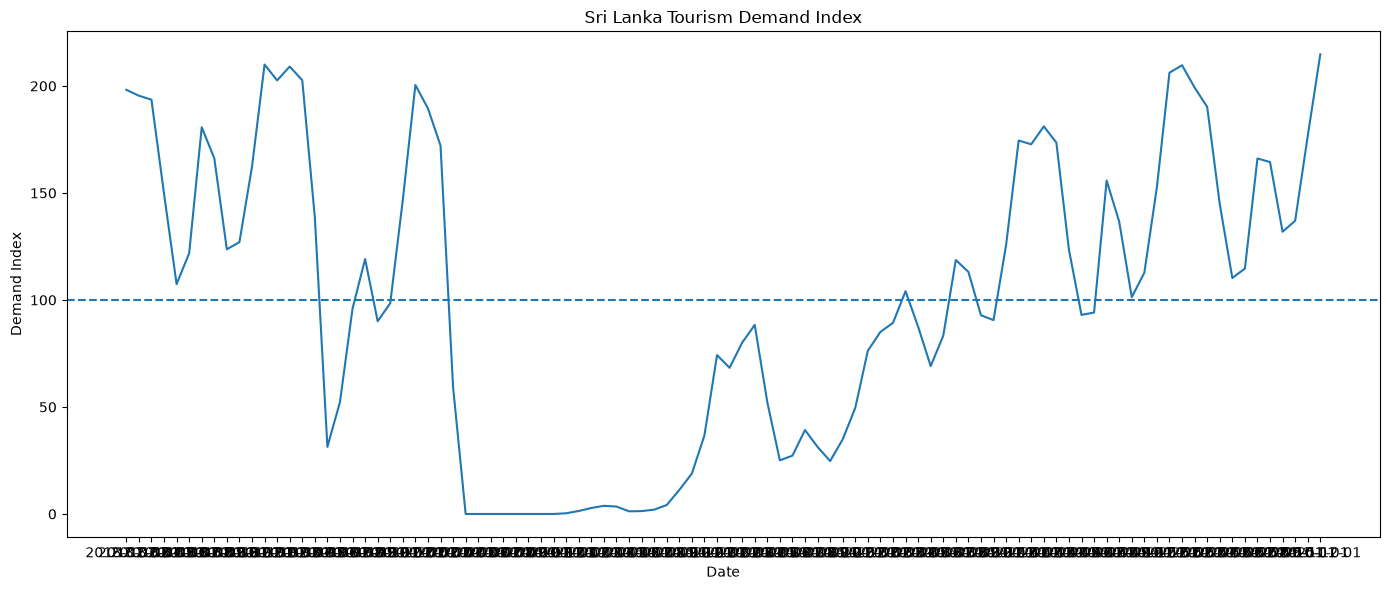

In [332]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly,
    x="Date",
    y="Demand_Index"
)

plt.axhline(
    100,
    linestyle="--"
)

plt.title("Sri Lanka Tourism Demand Index")

plt.ylabel("Demand Index")
plt.tight_layout()
plt.show()

### Time series analysis

In [333]:
monthly = (
    df.groupby("Date")["Tourist_Arrivals"]
    .sum()
    .sort_index()
)

monthly.index = pd.DatetimeIndex(
    monthly.index
)

monthly.head()

Date
2018-01-01    238924.0
2018-02-01    235618.0
2018-03-01    233382.0
2018-04-01    180429.0
2018-05-01    129466.0
Name: Tourist_Arrivals, dtype: float64

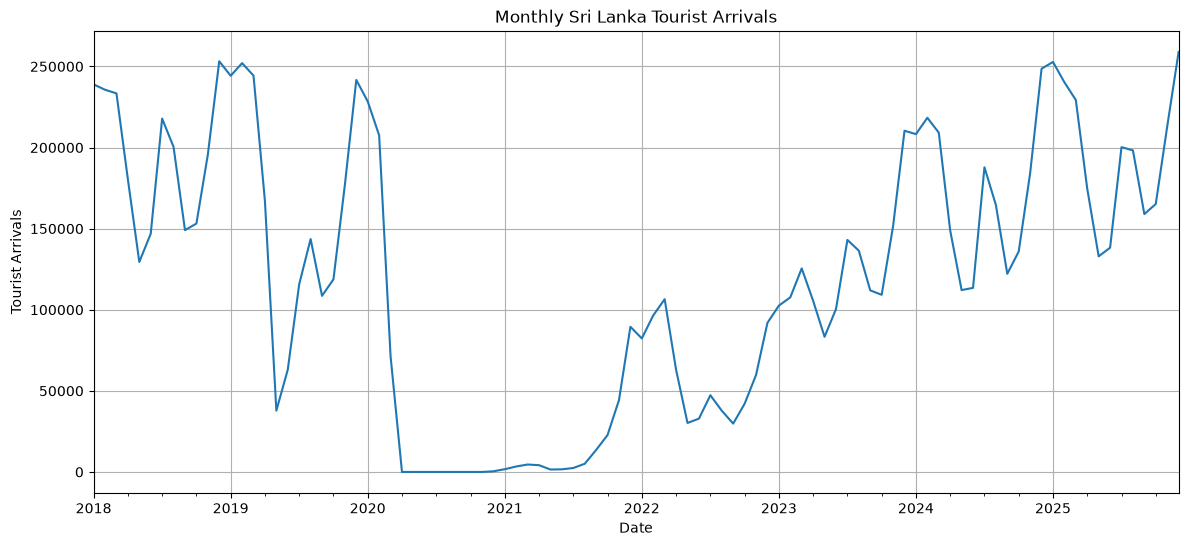

In [334]:
plt.figure(figsize=(14, 6))

monthly.plot()

plt.title("Monthly Sri Lanka Tourist Arrivals")
plt.ylabel("Tourist Arrivals")
plt.grid(True)
plt.show()

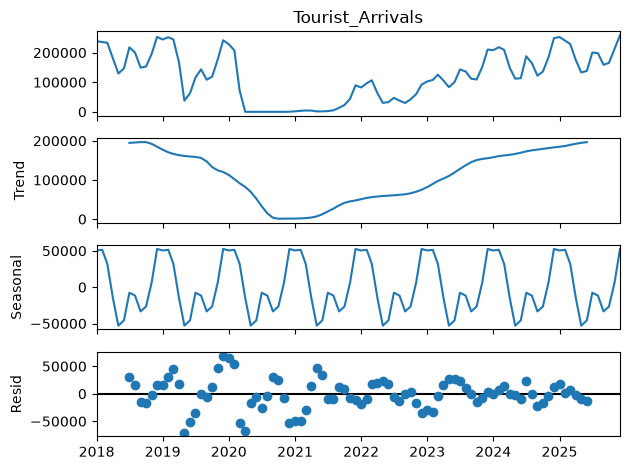

In [335]:
decomposition = seasonal_decompose(
    monthly,
    model="additive",
    period=12
)

decomposition.plot()

plt.tight_layout()
plt.show()

### Tourism forecasting

In [336]:
monthly = (
    df.groupby("Date")["Tourist_Arrivals"]
    .sum()
    .sort_index()
)

monthly.index = pd.DatetimeIndex(
    monthly.index
)

monthly = monthly.asfreq("MS")

In [337]:
train = monthly.iloc[:-12]
test = monthly.iloc[-12:]

print("Training:", len(train))
print("Testing:", len(test))

Training: 84
Testing: 12


In [338]:
model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit(
    disp=False
)

In [339]:
forecast = model_fit.forecast(
    steps=len(test)
)

forecast.index = test.index

In [340]:
mae = mean_absolute_error(
    test,
    forecast
)

rmse = np.sqrt(
    mean_squared_error(
        test,
        forecast
    )
)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 37318.47421366914
RMSE: 39751.17906852367


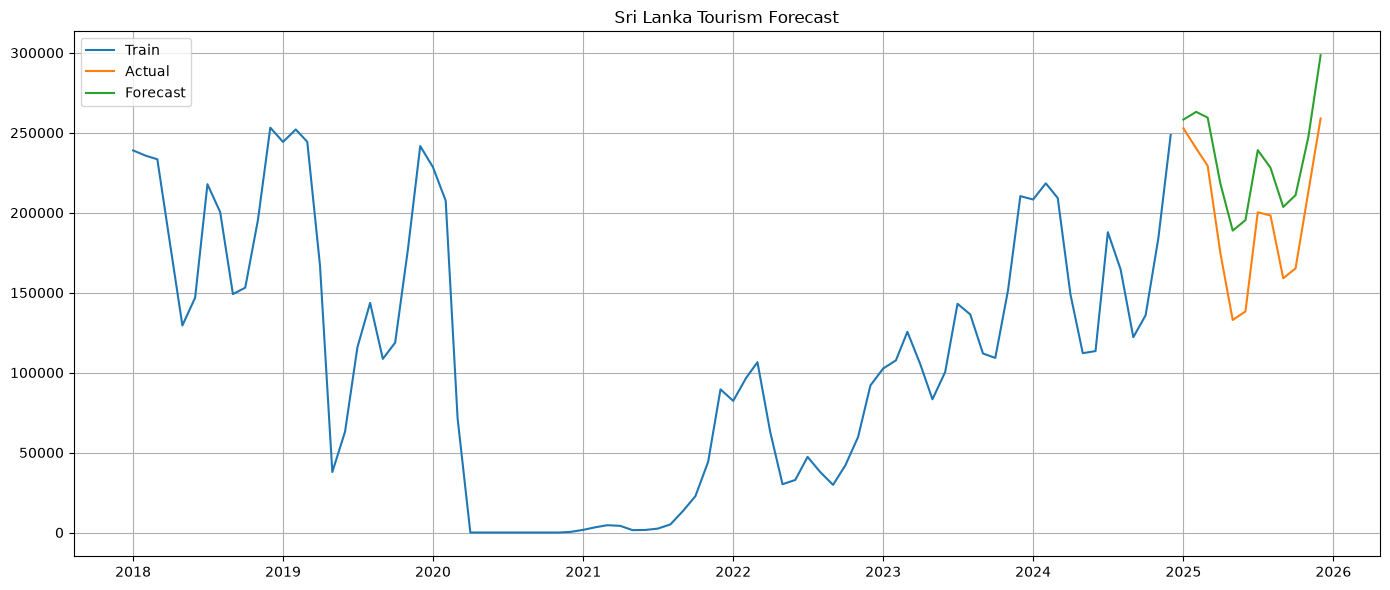

In [341]:
plt.figure(figsize=(14, 6))

plt.plot(
    train.index,
    train,
    label="Train"
)

plt.plot(
    test.index,
    test,
    label="Actual"
)

plt.plot(
    forecast.index,
    forecast,
    label="Forecast"
)

plt.title("Sri Lanka Tourism Forecast")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### What if scenario analysis

In [342]:
yearly = (
    df.groupby("Year")["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

latest_value = yearly[
    yearly["Year"] == yearly["Year"].max()
]["Tourist_Arrivals"].iloc[0]

print(
    "Latest tourism arrivals:",
    latest_value
)

Latest tourism arrivals: 2362521.0


In [343]:
scenarios = pd.DataFrame({
    "Scenario": [
        "Downside",
        "Baseline",
        "Growth +10%",
        "Growth +20%"
    ],
    
    "Change_%": [
        -10,
        0,
        10,
        20
    ]
})

scenarios["Projected_Arrivals"] = (
    latest_value
    * (1 + scenarios["Change_%"] / 100)
)

scenarios

,Scenario,Change_%,Projected_Arrivals
0,Downside,-10,2126268.9
1,Baseline,0,2362521.0
2,Growth +10%,10,2598773.1
3,Growth +20%,20,2835025.2


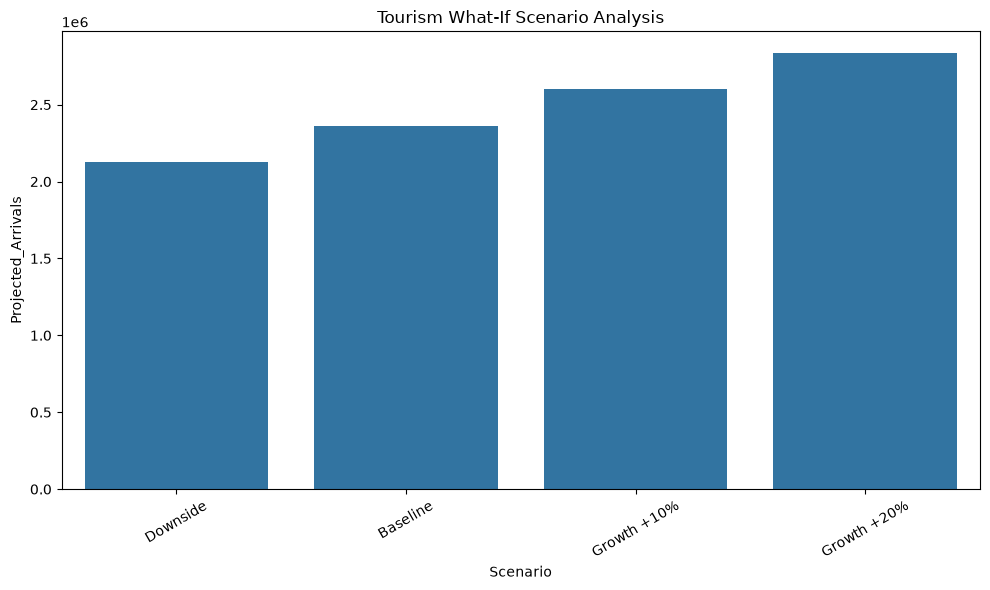

In [344]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=scenarios,
    x="Scenario",
    y="Projected_Arrivals"
)

plt.title(
    "Tourism What-If Scenario Analysis"
)

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Final business insights

In [345]:
total_arrivals = df[
    "Tourist_Arrivals"
].sum()

years = df["Year"].nunique()

countries = df["Country"].nunique()

average_monthly = (
    df.groupby("Date")["Tourist_Arrivals"]
    .sum()
    .mean()
)

print("Total Tourist Arrivals:", total_arrivals)
print("Years Covered:", years)
print("Countries Covered:", countries)
print("Average Monthly Arrivals:", average_monthly)

Total Tourist Arrivals: 11572959.0
Years Covered: 8
Countries Covered: 573
Average Monthly Arrivals: 120551.65625


In [346]:
yearly = (
    df.groupby("Year")["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

highest_year = yearly.loc[
    yearly["Tourist_Arrivals"].idxmax()
]

print(
    "Highest Tourism Year:",
    highest_year["Year"]
)

print(
    "Arrivals:",
    highest_year["Tourist_Arrivals"]
)

Highest Tourism Year: 2025.0
Arrivals: 2362521.0


In [347]:
lowest_year = yearly.loc[
    yearly["Tourist_Arrivals"].idxmin()
]

print(
    "Lowest Tourism Year:",
    lowest_year["Year"]
)

print(
    "Arrivals:",
    lowest_year["Tourist_Arrivals"]
)

Lowest Tourism Year: 2021.0
Arrivals: 194495.0


In [348]:
top_country = (
    df.groupby("Country")
    ["Tourist_Arrivals"]
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)

print(top_country)

Country
India                 1374333.0
Russian Federation     677270.0
United Kingdom         605891.0
UNITED KINGDOM         525053.0
INDIA                  500627.0
Germany                442131.0
INDIA, REPUBLIC OF     424887.0
GERMANY                338736.0
China                  337220.0
Australia              297420.0
Name: Tourist_Arrivals, dtype: float64


In [349]:
best_month = (
    df.groupby(
        ["Month_Number", "Month"]
    )["Tourist_Arrivals"]
    .sum()
    .sort_values(
        ascending=False
    )
    .head(1)
)

best_month

Month_Number  Month   
12            December    1394564.0
Name: Tourist_Arrivals, dtype: float64

In [350]:
yearly["Recovery_Index"] = (
    yearly["Tourist_Arrivals"]
    / yearly.loc[
        yearly["Year"] == 2019,
        "Tourist_Arrivals"
    ].iloc[0]
    * 100
)

yearly

,Year,Tourist_Arrivals,Recovery_Index
0,2018,2333796.0,121.951903
1,2019,1913702.0,100.000000
2,2020,507699.0,26.529679
3,2021,194495.0,10.163286
4,2022,719978.0,37.622263
5,2023,1487303.0,77.718631
6,2024,2053465.0,107.303279
7,2025,2362521.0,123.452920


In [351]:
top10 = (
    df.groupby("Country")
    ["Tourist_Arrivals"]
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)

top10

Country
India                 1374333.0
Russian Federation     677270.0
United Kingdom         605891.0
UNITED KINGDOM         525053.0
INDIA                  500627.0
Germany                442131.0
INDIA, REPUBLIC OF     424887.0
GERMANY                338736.0
China                  337220.0
Australia              297420.0
Name: Tourist_Arrivals, dtype: float64

NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
Country not found in regex
KOSOVAR not found in regex
Country not found in regex
KOSOVAR not found in regex
Coun

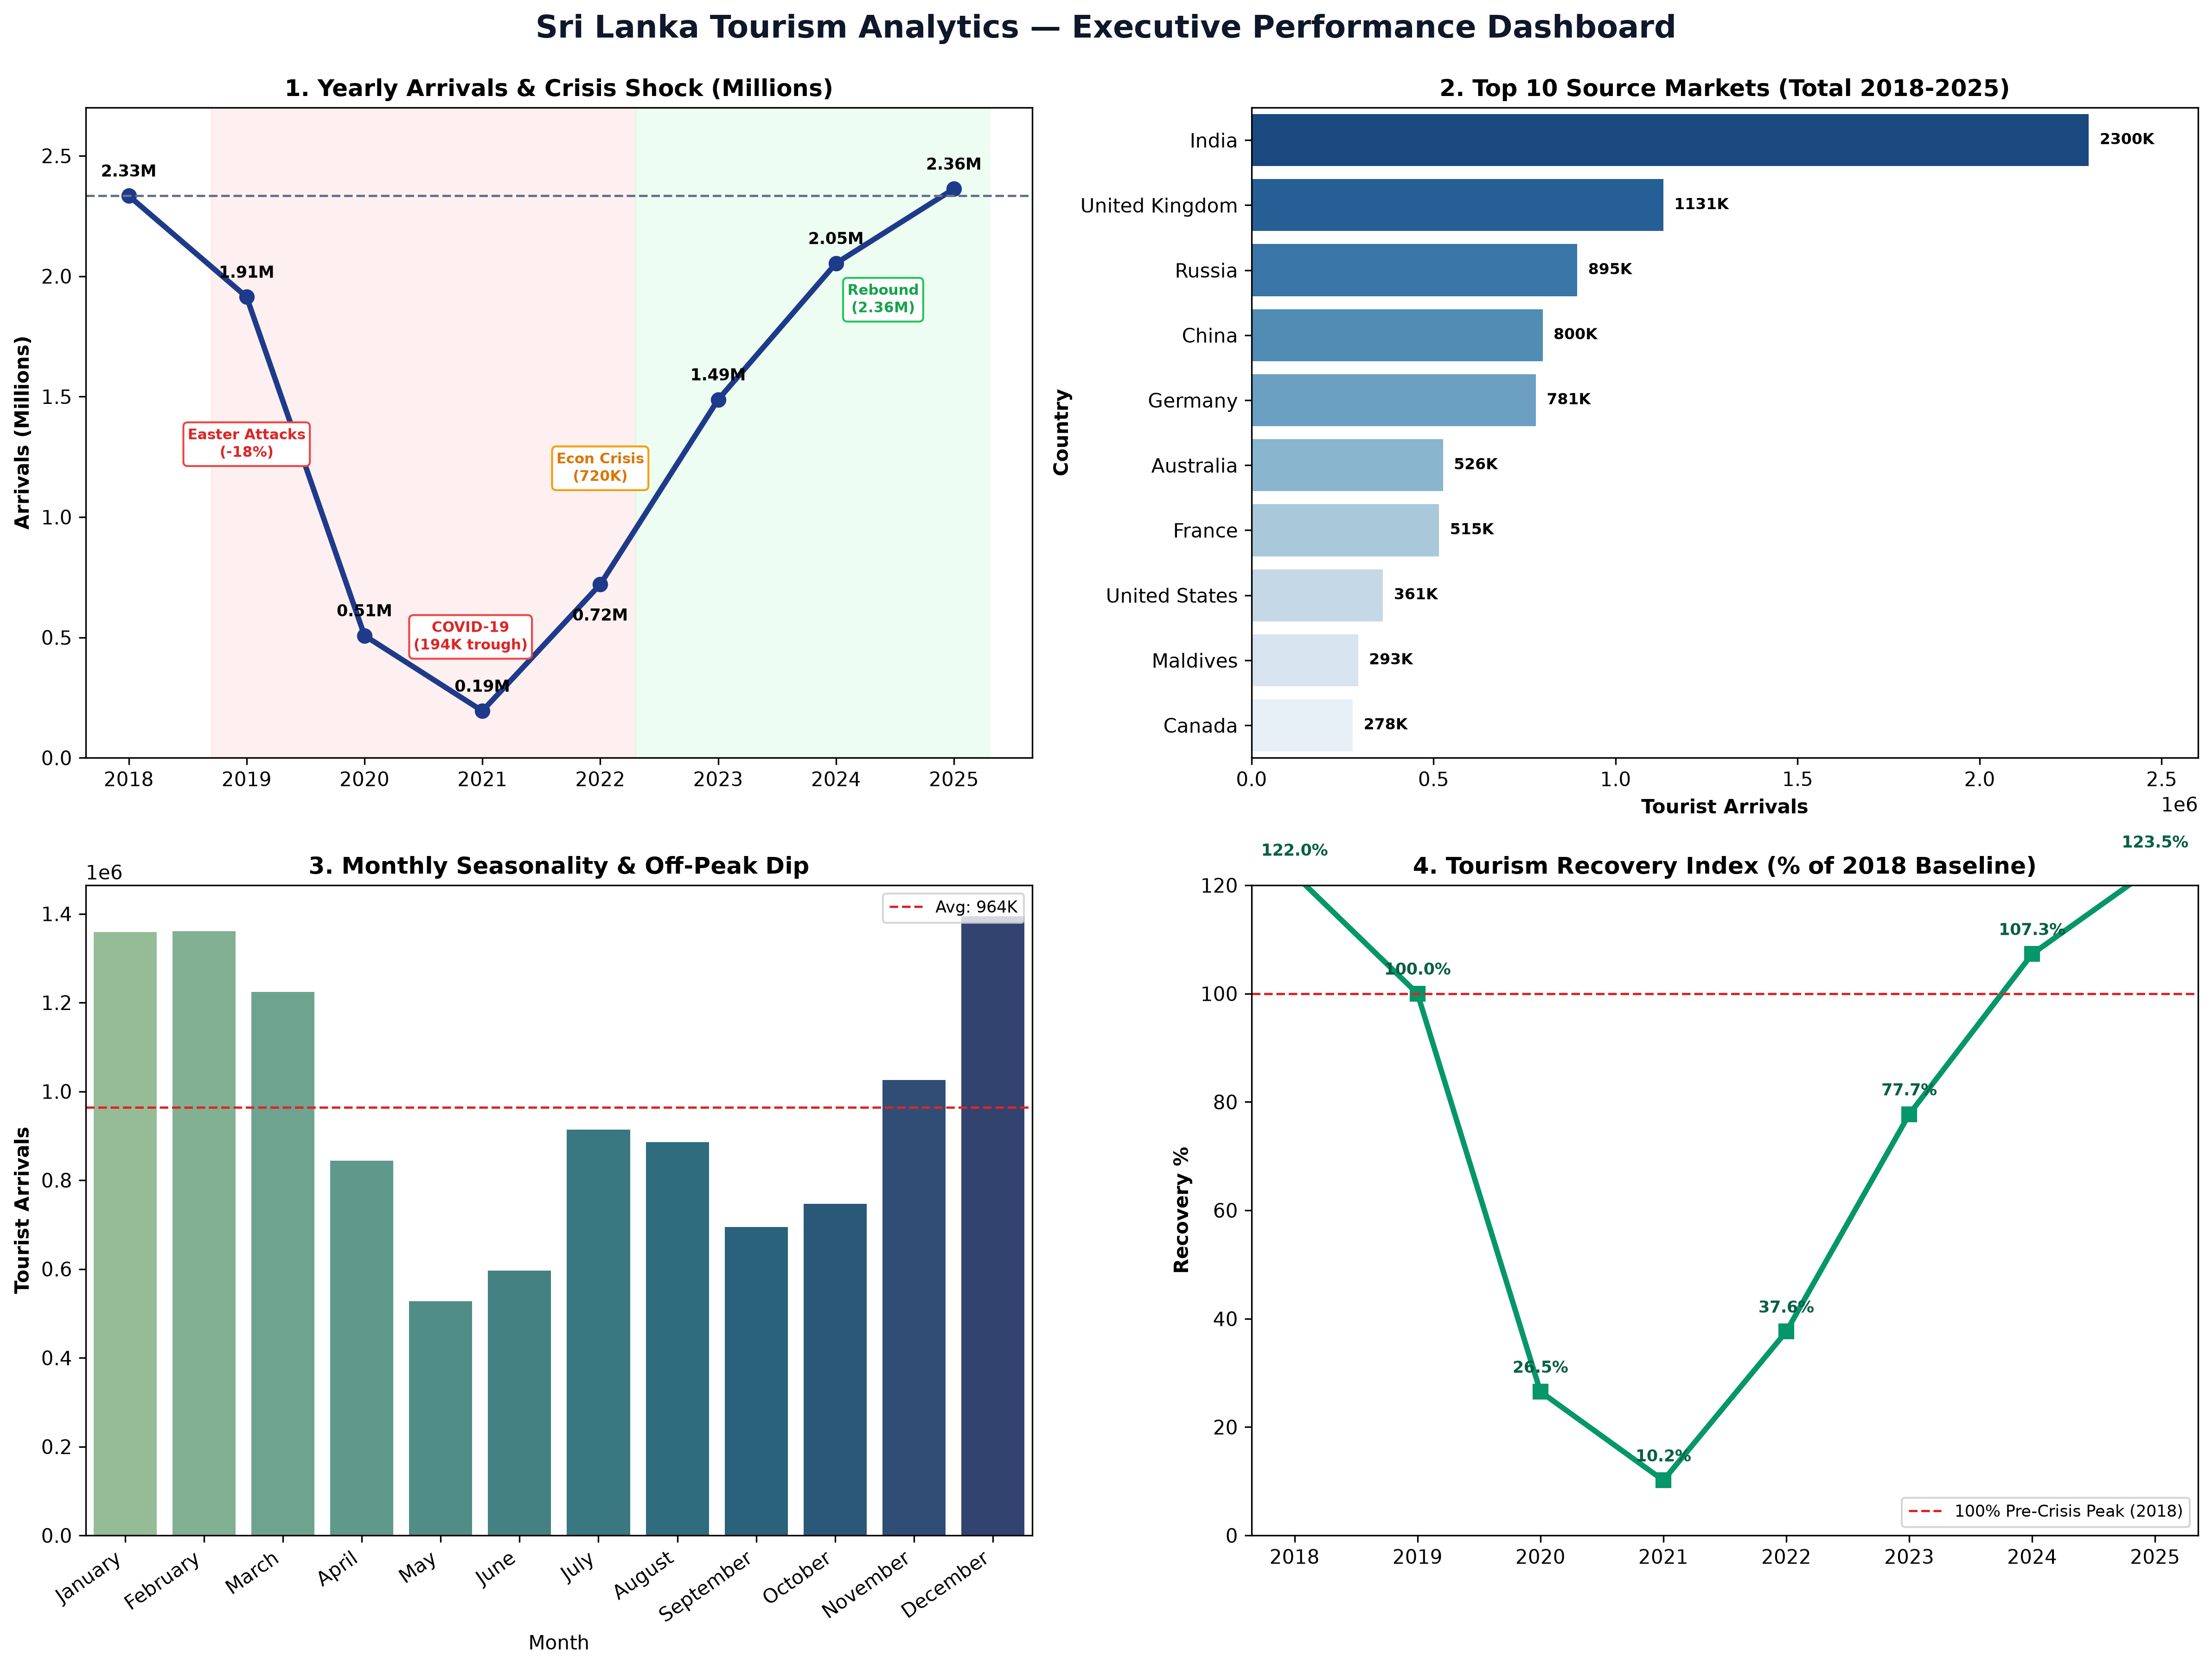

In [352]:

df_dash = df.copy()
converted_dash = coco.convert(names=df_dash['Country'].astype(str).tolist(), to='name_short', not_found=None)
df_dash['Standard_Country'] = [c if (c is not None and c != 'not found') else orig for c, orig in zip(converted_dash, df_dash['Country'])]
df_dash['Standard_Country'] = df_dash['Standard_Country'].replace({
    'Russian Federation': 'Russia',
    'United States of America': 'United States',
    'People\'s Republic of China': 'China'
})

country_top10 = (
    df_dash.groupby('Standard_Country')['Tourist_Arrivals']
    .sum()
    .sort_values(ascending=False)
    .drop(labels=['Other', 'Unknown'], errors='ignore')
    .head(10)
    .reset_index()
)

monthly_dash = (
    df.groupby(['Month_Number', 'Month'])['Tourist_Arrivals']
    .sum()
    .reset_index()
    .sort_values('Month_Number')
)
avg_mon = monthly_dash['Tourist_Arrivals'].mean()

fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=300)

# Panel (0,0): Yearly Crisis Timeline
ax_tl = axes[0, 0]
ax_tl.axvspan(2018.7, 2022.3, color='#fee2e2', alpha=0.5)
ax_tl.axvspan(2022.3, 2025.3, color='#dcfce7', alpha=0.5)
ax_tl.plot(yearly['Year'], yearly['Tourist_Arrivals']/1e6, color='#1e3a8a', lw=2.8, marker='o', markersize=7)
ax_tl.axhline(base_2018/1e6, color='#64748b', linestyle='--', lw=1.2)
ax_tl.set_title('1. Yearly Arrivals & Crisis Shock (Millions)', fontsize=12, fontweight='bold')
ax_tl.set_ylabel('Arrivals (Millions)', fontweight='bold')
ax_tl.set_ylim(0, 2.7)
for _, r in yearly.iterrows():
    y_pt = r['Tourist_Arrivals']/1e6
    y_shift = 0.08 if r['Year'] != 2022 else -0.15
    ax_tl.text(r['Year'], y_pt + y_shift, f"{y_pt:.2f}M", ha='center', fontsize=8.5, fontweight='bold')
ax_tl.text(2019, 1.25, 'Easter Attacks\n(-18%)', ha='center', fontsize=7.5, fontweight='bold', color='#dc2626', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#ef4444'))
ax_tl.text(2020.9, 0.45, 'COVID-19\n(194K trough)', ha='center', fontsize=7.5, fontweight='bold', color='#dc2626', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#ef4444'))
ax_tl.text(2022, 1.15, 'Econ Crisis\n(720K)', ha='center', fontsize=7.5, fontweight='bold', color='#d97706', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#f59e0b'))
ax_tl.text(2024.4, 1.85, 'Rebound\n(2.36M)', ha='center', fontsize=7.5, fontweight='bold', color='#16a34a', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#22c55e'))

# Panel (0,1): Top 10 Markets
ax_top = axes[0, 1]
sns.barplot(data=country_top10, y='Standard_Country', x='Tourist_Arrivals', palette='Blues_r', hue='Standard_Country', legend=False, ax=ax_top)
ax_top.set_title('2. Top 10 Source Markets (Total 2018-2025)', fontsize=12, fontweight='bold')
ax_top.set_xlabel('Tourist Arrivals', fontweight='bold')
ax_top.set_ylabel('Country', fontweight='bold')
ax_top.set_xlim(0, 2.6e6)
for p in ax_top.patches:
    width = p.get_width()
    ax_top.annotate(f"{width/1e3:.0f}K", (width + 30e3, p.get_y() + p.get_height()/2.), va='center', fontsize=8, fontweight='bold')

# Panel (1,0): Seasonality
ax_mon = axes[1, 0]
sns.barplot(data=monthly_dash, x='Month', y='Tourist_Arrivals', palette='crest', hue='Month', legend=False, ax=ax_mon)
ax_mon.axhline(avg_mon, color='#dc2626', linestyle='--', lw=1.2, label=f'Avg: {avg_mon/1e3:.0f}K')
ax_mon.set_title('3. Monthly Seasonality & Off-Peak Dip', fontsize=12, fontweight='bold')
ax_mon.set_ylabel('Tourist Arrivals', fontweight='bold')
ax_mon.set_xticks(range(len(monthly_dash['Month'])))
ax_mon.set_xticklabels(monthly_dash['Month'], rotation=35, ha='right')
ax_mon.legend(loc='upper right', fontsize=8.5)

# Panel (1,1): Recovery Index
ax_rec = axes[1, 1]
ax_rec.plot(yearly['Year'], yearly['Recovery_Index'], color='#059669', lw=2.8, marker='s', markersize=7)
ax_rec.axhline(100, color='#dc2626', linestyle='--', lw=1.2, label='100% Pre-Crisis Peak (2018)')
ax_rec.set_title('4. Tourism Recovery Index (% of 2018 Baseline)', fontsize=12, fontweight='bold')
ax_rec.set_ylabel('Recovery %', fontweight='bold')
ax_rec.set_ylim(0, 120)
for _, r in yearly.iterrows():
    ax_rec.text(r['Year'], r['Recovery_Index'] + 3.5, f"{r['Recovery_Index']:.1f}%", ha='center', fontsize=8.5, fontweight='bold', color='#065f46')
ax_rec.legend(loc='lower right', fontsize=8.5)

plt.suptitle('Sri Lanka Tourism Analytics — Executive Performance Dashboard', fontsize=16, fontweight='bold', y=0.995, color='#0f172a')
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'final_tourism_analysis.png', dpi=300)
plt.show()


### Automatically generate a final insights table

In [353]:
insights = []

best_year = yearly.loc[
    yearly["Tourist_Arrivals"].idxmax()
]

insights.append({
    "Insight": "Highest Tourism Year",
    "Value": best_year["Year"],
    "Metric": best_year["Tourist_Arrivals"]
})

worst_year = yearly.loc[
    yearly["Tourist_Arrivals"].idxmin()
]

insights.append({
    "Insight": "Lowest Tourism Year",
    "Value": worst_year["Year"],
    "Metric": worst_year["Tourist_Arrivals"]
})

best_country = (
    df.groupby("Country")["Tourist_Arrivals"]
    .sum()
    .idxmax()
)

best_country_value = (
    df.groupby("Country")["Tourist_Arrivals"]
    .sum()
    .max()
)

insights.append({
    "Insight": "Largest Source Market",
    "Value": best_country,
    "Metric": best_country_value
})

best_month_row = (
    df.groupby(
        ["Month_Number", "Month"]
    )["Tourist_Arrivals"]
    .sum()
    .idxmax()
)

best_month_value = (
    df.groupby(
        ["Month_Number", "Month"]
    )["Tourist_Arrivals"]
    .sum()
    .max()
)

insights.append({
    "Insight": "Highest Tourism Month",
    "Value": best_month_row[1],
    "Metric": best_month_value
})

insights_df = pd.DataFrame(insights)

insights_df

,Insight,Value,Metric
0,Highest Tourism Year,2025.0,2362521.0
1,Lowest Tourism Year,2021.0,194495.0
2,Largest Source Market,India,1374333.0
3,Highest Tourism Month,December,1394564.0


## Actionable Business Recommendations

### 1. Off-Peak Demand Smoothing (May–June Monsoon Trough)
- **Tactical Campaign:** Launch targeted seasonal wellness, Ayurveda, and MICE (Meetings, Incentives, Conferences, Exhibitions) packages during May–June.
- **Target Markets:** Regional short-haul markets with high summer travel propensity (India, GCC, Singapore) where travel friction and flight times are minimal.
- **Incentives:** Partner with airlines (SriLankan Airlines, IndiGo, Emirates) for discounted off-peak seat capacity and bundled hotel packages.

### 2. High-Yield Winter Campaign Lead-Time (December–February Peak)
- **Execution Timing:** Initiate digital marketing and trade roadshows in key European source markets (UK, Germany, France) **3 months in advance (September–October)** to influence long-haul winter vacation bookings.
- **Value Proposition:** Promote premium beach escapes, wildlife safaris, and cultural heritage circuits to maximize length-of-stay and per-tourist expenditure.

### 3. Source Market Diversification & Risk Mitigation
- **Reduce Concentration:** India represents ~20% of inbound arrivals. To mitigate single-market geopolitical and economic shocks, actively cultivate high-growth secondary markets (Australia, China, Scandinavian countries, Eastern Europe).
- **Currency & Billing Alignment:** Introduce local-currency digital payment methods (UPI for Indian visitors, Alipay/WeChat Pay for Chinese visitors) to lower foreign exchange friction.

### 4. Dynamic Crisis Resilience & Capacity Planning
- **Scenario Playbooks:** Establish predefined crisis operational protocols based on the 2019–2022 recovery trajectory (flexible booking cancellation policies, emergency fuel/power utility assurances for hospitality).
- **Infrastructure Alignment:** Expand airport transit capacity and fast-track immigration counters during peak arrival months (December: ~1.39M historical arrivals across data window) to prevent operational bottlenecks.


In [354]:
insights_df.to_csv(TABLES_PATH / "final_business_insights.csv", index=False)

print(
    "Final business insights saved."
)

Final business insights saved.
